## 0. Imports & path setup

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from src.random_forest_genre import GenreClassifier

## 1. Load data

In [12]:
df = pd.read_csv("../data/raw data/best sellin books total.csv")
df.columns = df.columns.str.strip()
print(f'Shape: {df.shape}')
df.head()

Shape: (210, 13)


,Book name,Author,Rating,reviews count,form,price range,Reading age,Print Length,Publishing date,Genre,id_2023,id_2024,id_2025
0,Atomic Habits: An Easy & Proven Way to Build G...,James Clear,4.8 out of 5 stars,145747,Hardcover,$15–$25,for all,320,16/10/2018,Self-Improvement,#1,#3,#6
1,"Iron Flame (Standard Edition) (The Empyrean, 2)",Rebecca Yarros,4.7 out of 5 stars,395512,Hardcover,$5–$15,adult,640,7/11/2023,Fiction & Action & Adventure,#2,#13,NaN
2,Spare,Prince Harry The Duke of Sussex,4.5 out of 5 stars,116101,Hardcover,$5–$15,for all,416,10-Jan-23,Biographies & Memoirs,#3,NaN,NaN
3,Fourth Wing,Rebecca Yarros,4.8 out of 5 stars,472618,Paperback,$5–$15,adult,544,17/09/2024,Fiction & Action & Adventure,#4,#16,#76
4,The Woman in Me,Britney Spears,4.4 out of 5 stars,51520,Hardcover,$5–$15,adult,288,24-Oct-23,Biographies & Memoirs,#5,NaN,NaN


## 2. Explore the target

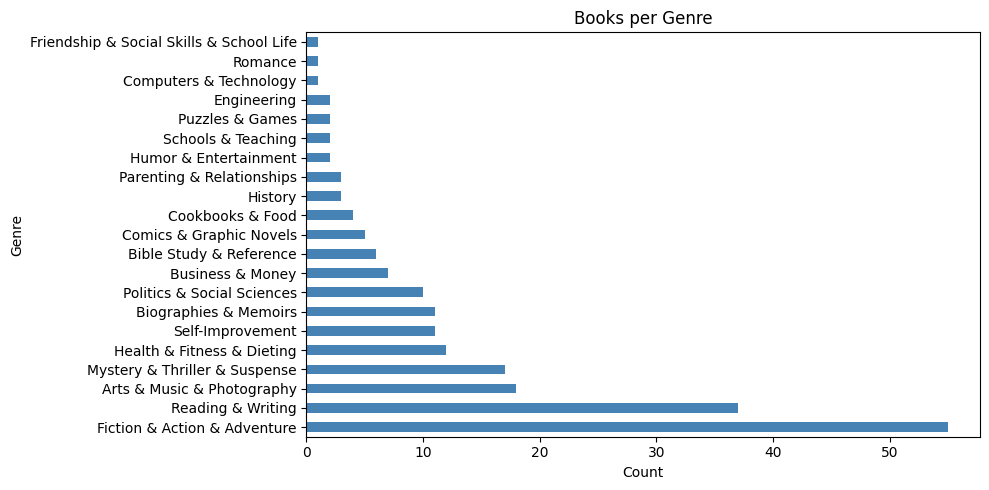

Genre
Fiction & Action & Adventure                55
Reading & Writing                           37
Arts & Music & Photography                  18
Mystery & Thriller & Suspense               17
Health & Fitness & Dieting                  12
Self-Improvement                            11
Biographies & Memoirs                       11
Politics & Social Sciences                  10
Business & Money                             7
Bible Study & Reference                      6
Comics & Graphic Novels                      5
Cookbooks & Food                             4
History                                      3
Parenting & Relationships                    3
Humor & Entertainment                        2
Schools & Teaching                           2
Puzzles & Games                              2
Engineering                                  2
Computers & Technology                       1
Romance                                      1
Friendship & Social Skills & School Life     1
Name: c

In [13]:
import matplotlib.pyplot as plt

genre_counts = df['Genre'].value_counts()
fig, ax = plt.subplots(figsize=(10, 5))
genre_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Books per Genre')
ax.set_xlabel('Count')
fig.tight_layout()
plt.show()
print(genre_counts)

## 3. Train the model

In [14]:
clf = GenreClassifier(
    n_estimators=200,
    test_size=0.2,
    random_state=42,
)

clf.fit(df)
print('Training complete.')

Note: stratification skipped — some genre classes have < 2 samples.
Training complete.


## 4. Evaluate

In [8]:
results = clf.evaluate()

c:\Users\emmad\anaconda3\envs\myenv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


  RANDOM FOREST — GENRE CLASSIFICATION
  Test Accuracy  : 0.4524
  5-Fold CV Acc  : 0.5857 ± 0.0387

                                          precision    recall  f1-score   support

              Arts & Music & Photography       1.00      1.00      1.00         3
                 Bible Study & Reference       0.00      0.00      0.00         3
                   Biographies & Memoirs       0.00      0.00      0.00         2
                        Business & Money       0.00      0.00      0.00         3
                 Comics & Graphic Novels       0.50      1.00      0.67         1
                        Cookbooks & Food       1.00      1.00      1.00         2
                             Engineering       0.00      0.00      0.00         1
            Fiction & Action & Adventure       0.62      0.89      0.73         9
Friendship & Social Skills & School Life       0.00      0.00      0.00         1
              Health & Fitness & Dieting       1.00      0.20      0.33       

## 5. Feature importance

Saved: rf_genre_feature_importance.png


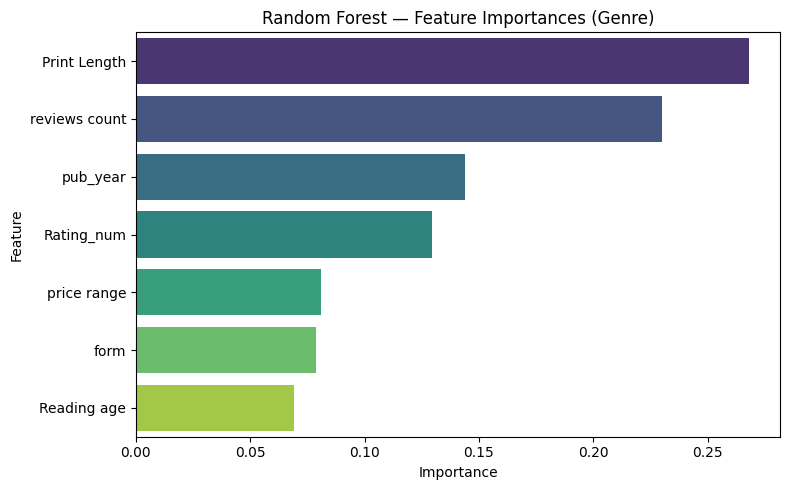

In [9]:
clf.plot_feature_importance(save_path='rf_genre_feature_importance.png')

## 6. Confusion matrix (top 10 genres)

Saved: rf_genre_confusion_matrix.png


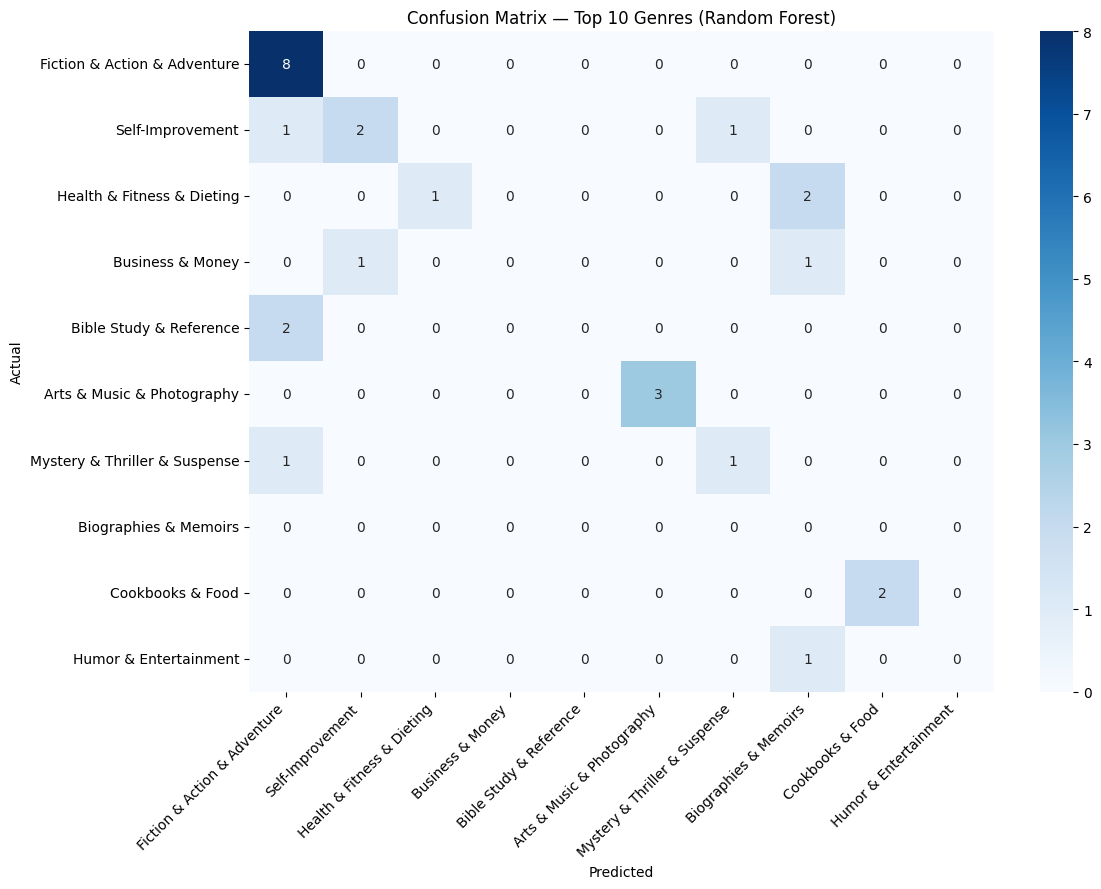

In [10]:
clf.plot_confusion_matrix(top_n=10, save_path='rf_genre_confusion_matrix.png')